## Set-up

In [1]:
import cv2
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output
from PIL import Image

In [2]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


In [3]:
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

## Selecting objects with SAM 2

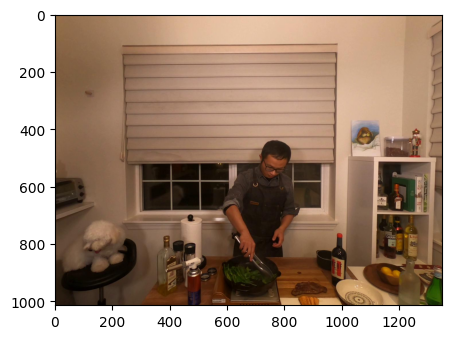

In [4]:
image = Image.open('data/dynerf/cook_spinach/cam00/images/0000.jpg')
image = np.array(image.convert("RGB"))
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis('on')
plt.show()

In [5]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_checkpoint = "submodules/sam2/checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

predictor = SAM2ImagePredictor(sam2_model)

Process the image to produce an image embedding by calling `SAM2ImagePredictor.set_image`. `SAM2ImagePredictor` remembers this embedding and will use it for subsequent mask prediction.

In [6]:
predictor.set_image(image)

### Points selection

To select the guy, choose a point on it. Points are input to the model in (x,y) format and come with labels 1 (foreground point) or 0 (background point). Multiple points can be input; here we use only one. The chosen point will be shown as a star on the image.

In [7]:
input_point = np.array([[750, 600]])
input_label = np.array([1])

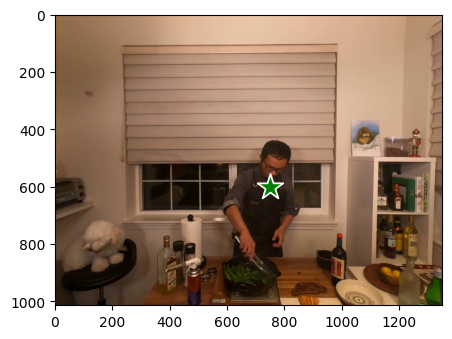

In [8]:
plt.figure(figsize=(5, 5))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()  

In [9]:
print(predictor._features["image_embed"].shape, predictor._features["image_embed"][-1].shape)

torch.Size([1, 256, 64, 64]) torch.Size([256, 64, 64])


Predict with `SAM2ImagePredictor.predict`. The model returns masks, quality predictions for those masks, and low resolution mask logits that can be passed to the next iteration of prediction.

In [10]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)
sorted_ind = np.argsort(scores)[::-1]
masks = masks[sorted_ind]
scores = scores[sorted_ind]
logits = logits[sorted_ind]

With `multimask_output=True` (the default setting), SAM 2 outputs 3 masks, where `scores` gives the model's own estimation of the quality of these masks. This setting is intended for ambiguous input prompts, and helps the model disambiguate different objects consistent with the prompt. When `False`, it will return a single mask. For ambiguous prompts such as a single point, it is recommended to use `multimask_output=True` even if only a single mask is desired; the best single mask can be chosen by picking the one with the highest score returned in `scores`. This will often result in a better mask.

In [11]:
print(f"{masks.shape = }")  # (number_of_masks) x H x W
print(f"{logits.shape = }")

masks.shape = (3, 1014, 1352)
logits.shape = (3, 256, 256)


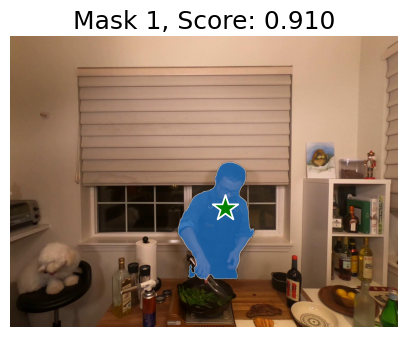

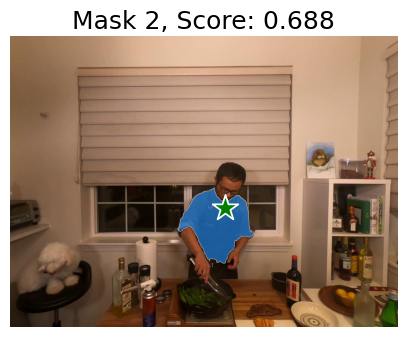

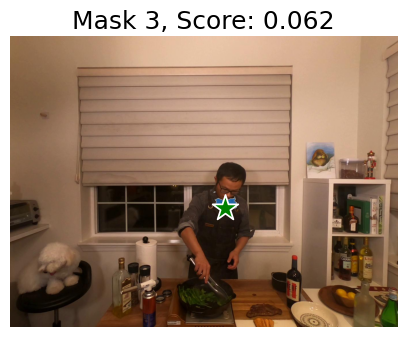

In [12]:
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=True)

### Box selection

In [13]:
# top left and bottom right points
input_box = np.array([
    [600, 400, 850, 850]
])

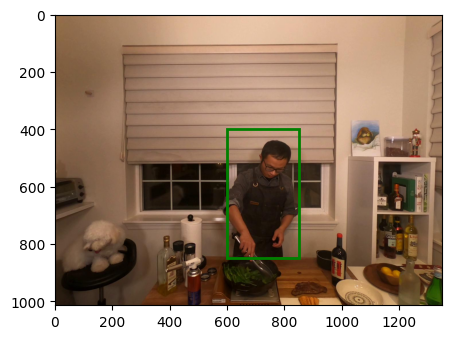

In [14]:
plt.figure(figsize=(5, 5))
plt.imshow(image)
show_box(input_box[0], plt.gca())
plt.axis('on')
plt.show()  

In [15]:
masks, scores, logits = predictor.predict(
    box=input_box,
    # point_coords=input_point,
    # point_labels=input_label,
    multimask_output=False,
)

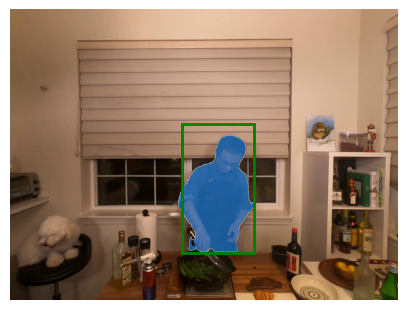

In [16]:
show_masks(image, masks, scores, box_coords=input_box[0])

## Specifying a specific object with additional points

The single input point is ambiguous, and the model has returned multiple objects consistent with it. To obtain a single object, multiple points can be provided. If available, a mask from a previous iteration can also be supplied to the model to aid in prediction. When specifying a single object with multiple prompts, a single mask can be requested by setting `multimask_output=False`.

In [17]:
input_point = np.array([[750, 600], [750, 800]])
input_label = np.array([1, 1])

mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

In [18]:
masks, scores, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

In [19]:
masks.shape

(1, 1014, 1352)

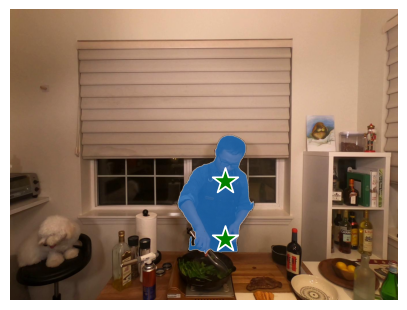

In [20]:
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label)

## Predict Batch

In [21]:
# Read images from data/dynerf/cook_spinach/cam00/images
image_dir = 'data/dynerf/cook_spinach/time0'

def get_image_files(image_dir: str) -> list[str]:
    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')],
                         key=lambda x: int(os.path.splitext(x)[0].split('_')[-1]))
    return image_files

# An image reader, loading images on the fly
def image_reader(image_dir):
    image_files = get_image_files(image_dir)
    print(image_files)
    for image_file in image_files:
        image_path = os.path.join(image_dir, image_file)
        image = Image.open(image_path).convert("RGB")
        yield np.array(image)

        
images = list(image_reader(image_dir))

['original_time0_0.jpg', 'original_time0_1.jpg', 'original_time0_2.jpg', 'original_time0_3.jpg', 'original_time0_4.jpg', 'original_time0_5.jpg', 'original_time0_6.jpg', 'original_time0_7.jpg', 'original_time0_8.jpg', 'original_time0_9.jpg', 'original_time0_10.jpg', 'original_time0_11.jpg', 'original_time0_12.jpg', 'original_time0_13.jpg', 'original_time0_14.jpg', 'original_time0_15.jpg', 'original_time0_16.jpg', 'original_time0_17.jpg', 'original_time0_18.jpg', 'original_time0_19.jpg', 'original_time0_20.jpg']


In [22]:
input_point = np.array([
    [[550, 450], [550, 600]],
    [[710, 400], [710, 650]],
    [[700, 420], [700, 600]],
    [[630, 410], [630, 600]],
    [[600, 450], [600, 600]],
    [[600, 450], [600, 600]],
    [[500, 450], [500, 600]],
    [[500, 450], [500, 600]],
    [[450, 450], [450, 600]],
    [[400, 450], [350, 620]],
    [[400, 400], [330, 630]],
    [[480, 410], [410, 600]],
    [[450, 380], [410, 550]],
    [[600, 360], [600, 530]],
    [[600, 360], [600, 530]],
    [[550, 360], [550, 530]],
    [[550, 360], [550, 530]],
    [[500, 360], [500, 530]],
    [[500, 360], [500, 530]],
    [[590, 420], [590, 600]],
    [[500, 500], [500, 640]],
])
input_label = np.array([
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 1],
])

#### Check single image

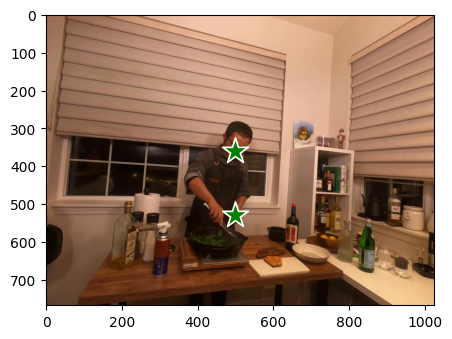

In [23]:
idx = 18
plt.figure(figsize=(5, 5))
plt.imshow(images[idx])
show_points(input_point[idx], input_label[idx], plt.gca())
plt.axis('on')
plt.show()  

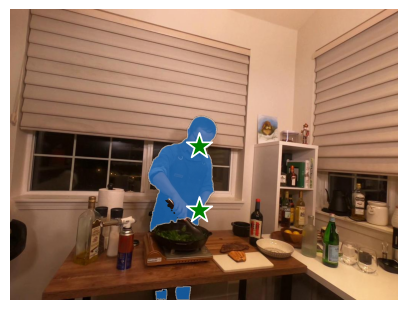

In [24]:
predictor.set_image(images[idx])
masks, scores, logits = predictor.predict(
    point_coords=input_point[idx],
    point_labels=input_label[idx],
    multimask_output=False,
)

plt.figure(figsize=(5, 5))
plt.imshow(images[idx])
show_mask(masks[0], plt.gca())
show_points(input_point[idx], input_label[idx], plt.gca())
plt.axis('off')
plt.show()

### Batch Processing

In [25]:
predictor.set_image_batch(images)
masks_batch, scores_batch, _  = predictor.predict_batch(
    point_coords_batch=input_point,
    point_labels_batch=input_label,
    multimask_output=False
)

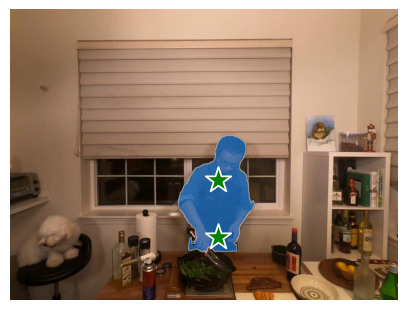

In [26]:
for idx in range(21):
    clear_output()
    plt.figure(figsize=(5, 5))
    plt.imshow(images[idx])
    show_mask(masks_batch[idx][0], plt.gca())
    show_points(input_point[idx], input_label[idx], plt.gca())
    plt.axis('off')
    plt.show()
    interactive = input("Press Enter to continue to the next frame, or type 'exit' to stop: ")
    if interactive.lower() == 'exit':
        break

### Save Masks

In [27]:
mask_gray = np.array(masks_batch).squeeze() # [n, 1, h, w] -> [n, h, w]
mask_gray = mask_gray * 255 # binary to gray scale image

In [28]:
# Save images
save_dir = "data/dynerf/cook_spinach/object_mask"
os.makedirs(save_dir, exist_ok=True)
image_files = get_image_files(image_dir)

for mask, img_name in zip(mask_gray, image_files):
    index = int(os.path.splitext(img_name)[0].split('_')[-1])
    filename = f"{index:02}.jpg"
    save_path = os.path.join(save_dir, filename)
    print(save_path)
    cv2.imwrite(save_path, mask)

data/dynerf/cook_spinach/object_mask/00.jpg
data/dynerf/cook_spinach/object_mask/01.jpg
data/dynerf/cook_spinach/object_mask/02.jpg
data/dynerf/cook_spinach/object_mask/03.jpg
data/dynerf/cook_spinach/object_mask/04.jpg
data/dynerf/cook_spinach/object_mask/05.jpg
data/dynerf/cook_spinach/object_mask/06.jpg
data/dynerf/cook_spinach/object_mask/07.jpg
data/dynerf/cook_spinach/object_mask/08.jpg
data/dynerf/cook_spinach/object_mask/09.jpg
data/dynerf/cook_spinach/object_mask/10.jpg
data/dynerf/cook_spinach/object_mask/11.jpg
data/dynerf/cook_spinach/object_mask/12.jpg
data/dynerf/cook_spinach/object_mask/13.jpg
data/dynerf/cook_spinach/object_mask/14.jpg
data/dynerf/cook_spinach/object_mask/15.jpg
data/dynerf/cook_spinach/object_mask/16.jpg
data/dynerf/cook_spinach/object_mask/17.jpg
data/dynerf/cook_spinach/object_mask/18.jpg
data/dynerf/cook_spinach/object_mask/19.jpg
data/dynerf/cook_spinach/object_mask/20.jpg


[ WARN:0@47.903] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


### Partial Editing

In [29]:
# Load Pix2Pix modified images
inpaint_images_dir = "data/dynerf/cook_spinach/painting"
inpaint_images = list(image_reader(inpaint_images_dir))

['edited_painting_original_time0_0.jpg', 'edited_painting_original_time0_1.jpg', 'edited_painting_original_time0_2.jpg', 'edited_painting_original_time0_3.jpg', 'edited_painting_original_time0_4.jpg', 'edited_painting_original_time0_5.jpg', 'edited_painting_original_time0_6.jpg', 'edited_painting_original_time0_7.jpg', 'edited_painting_original_time0_8.jpg', 'edited_painting_original_time0_9.jpg', 'edited_painting_original_time0_10.jpg', 'edited_painting_original_time0_11.jpg', 'edited_painting_original_time0_12.jpg', 'edited_painting_original_time0_13.jpg', 'edited_painting_original_time0_14.jpg', 'edited_painting_original_time0_15.jpg', 'edited_painting_original_time0_16.jpg', 'edited_painting_original_time0_17.jpg', 'edited_painting_original_time0_18.jpg', 'edited_painting_original_time0_19.jpg', 'edited_painting_original_time0_20.jpg']


In [30]:
# edit images
masks          = np.array(masks_batch).squeeze() != 0.0
image_edited   = np.array(images)
inpaint_images = np.array(inpaint_images)
image_edited[masks] = inpaint_images[masks]

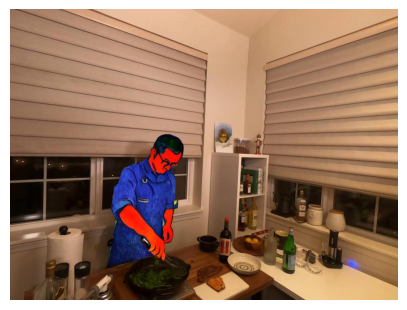

In [31]:
# show one result
plt.figure(figsize=(5, 5))
plt.imshow(image_edited[10])
plt.axis('off')
plt.show()

In [32]:
# Save images
save_dir = "data/dynerf/cook_spinach/partial_edited"
os.makedirs(save_dir, exist_ok=True)
image_files = get_image_files(inpaint_images_dir)

BGR_edited = image_edited[:,:,:,::-1] # RGB to BGR

for edited_image, img_name in zip(BGR_edited, image_files):
    index = int(os.path.splitext(img_name)[0].split('_')[-1])
    filename = f"{index:02}.jpg"
    save_path = os.path.join(save_dir, filename)
    print(save_path)
    cv2.imwrite(save_path, edited_image)

data/dynerf/cook_spinach/partial_edited/00.jpg
data/dynerf/cook_spinach/partial_edited/01.jpg
data/dynerf/cook_spinach/partial_edited/02.jpg
data/dynerf/cook_spinach/partial_edited/03.jpg
data/dynerf/cook_spinach/partial_edited/04.jpg
data/dynerf/cook_spinach/partial_edited/05.jpg
data/dynerf/cook_spinach/partial_edited/06.jpg
data/dynerf/cook_spinach/partial_edited/07.jpg
data/dynerf/cook_spinach/partial_edited/08.jpg
data/dynerf/cook_spinach/partial_edited/09.jpg
data/dynerf/cook_spinach/partial_edited/10.jpg
data/dynerf/cook_spinach/partial_edited/11.jpg
data/dynerf/cook_spinach/partial_edited/12.jpg
data/dynerf/cook_spinach/partial_edited/13.jpg
data/dynerf/cook_spinach/partial_edited/14.jpg
data/dynerf/cook_spinach/partial_edited/15.jpg
data/dynerf/cook_spinach/partial_edited/16.jpg
data/dynerf/cook_spinach/partial_edited/17.jpg
data/dynerf/cook_spinach/partial_edited/18.jpg
data/dynerf/cook_spinach/partial_edited/19.jpg
data/dynerf/cook_spinach/partial_edited/20.jpg
